# Лабораторная работа №4
## Линейные модели, SVM и деревья решений
---

## Импорт библиотек и загрузка данных

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

import warnings
warnings.filterwarnings('ignore')

In [112]:
digits = load_digits()

df = pd.DataFrame(data=digits.data, columns=digits.feature_names)
df['target'] = digits.target
df['target_name'] = df['target'].map({i: name for i, name in enumerate(digits.target_names)})

df.head(10)

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target,target_name
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4,4
5,0.0,0.0,12.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,9.0,16.0,16.0,10.0,0.0,0.0,5,5
6,0.0,0.0,0.0,12.0,13.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,9.0,15.0,11.0,3.0,0.0,6,6
7,0.0,0.0,7.0,8.0,13.0,16.0,15.0,1.0,0.0,0.0,...,0.0,0.0,13.0,5.0,0.0,0.0,0.0,0.0,7,7
8,0.0,0.0,9.0,14.0,8.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,11.0,16.0,15.0,11.0,1.0,0.0,8,8
9,0.0,0.0,11.0,12.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,9.0,12.0,13.0,3.0,0.0,0.0,9,9


## Подготовка данных

In [113]:
X = df[digits.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [114]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Обучение моделей

#### Логистическая регрессия

In [115]:
lr_model = LogisticRegression(max_iter=5000, random_state=42, solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f'Accuracy: {lr_accuracy:.4f}')
print(f'F1-score (weighted): {lr_f1:.4f}')
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.9815
F1-score (weighted): 0.9816
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.95      0.95      0.95        55
           2       1.00      1.00      1.00        53
           3       1.00      1.00      1.00        55
           4       0.98      0.98      0.98        54
           5       1.00      0.98      0.99        55
           6       1.00      0.98      0.99        54
           7       1.00      1.00      1.00        54
           8       0.91      0.94      0.92        52
           9       0.98      0.98      0.98        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



#### SVM

In [116]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

print(f'Accuracy: {svm_accuracy:.4f}')
print(f'F1-score (weighted): {svm_f1:.4f}')
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.9833
F1-score (weighted): 0.9833
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        54
           1       0.96      0.98      0.97        55
           2       1.00      0.98      0.99        53
           3       1.00      1.00      1.00        55
           4       0.95      0.98      0.96        54
           5       1.00      0.98      0.99        55
           6       0.98      1.00      0.99        54
           7       0.96      1.00      0.98        54
           8       1.00      0.94      0.97        52
           9       0.98      0.96      0.97        54

    accuracy                           0.98       540
   macro avg       0.98      0.98      0.98       540
weighted avg       0.98      0.98      0.98       540



#### Дерево решений

In [117]:
dt_model = DecisionTreeClassifier(max_depth=7, random_state=42)
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print(f'Accuracy: {dt_accuracy:.4f}')
print(f'F1-score (weighted): {dt_f1:.4f}')
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.8259
F1-score (weighted): 0.8266
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        54
           1       0.76      0.75      0.75        55
           2       0.77      0.81      0.79        53
           3       0.84      0.84      0.84        55
           4       0.80      0.87      0.83        54
           5       0.92      0.87      0.90        55
           6       0.98      0.94      0.96        54
           7       0.81      0.81      0.81        54
           8       0.71      0.75      0.73        52
           9       0.75      0.70      0.72        54

    accuracy                           0.83       540
   macro avg       0.83      0.83      0.83       540
weighted avg       0.83      0.83      0.83       540



## Сравнение моделей

In [118]:
results = pd.DataFrame({
    'Модель': ['Логистическая регрессия', 'SVM (RBF)', 'Дерево решений'],
    'Accuracy': [lr_accuracy, svm_accuracy, dt_accuracy],
    'F1-score (weighted)': [lr_f1, svm_f1, dt_f1]
})

results

,Модель,Accuracy,F1-score (weighted)
0,Логистическая регрессия,0.981481,0.981604
1,SVM (RBF),0.983333,0.983342
2,Дерево решений,0.825926,0.826552


## Важность признаков в дереве решений

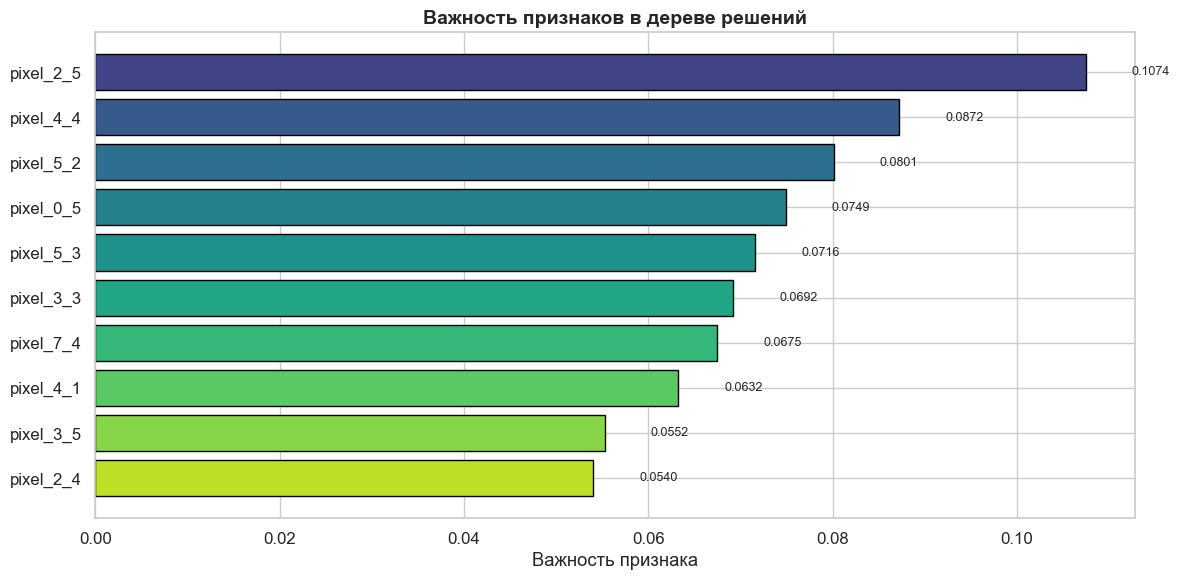

In [119]:
importances = dt_model.feature_importances_
feature_names = digits.feature_names

indices = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(12, 6))

sorted_features = [feature_names[i] for i in indices][:10]
sorted_importances = importances[indices][:10]

bars = ax.barh(range(len(sorted_features)), sorted_importances, 
               color=plt.cm.viridis(np.linspace(0.2, 0.9, len(sorted_features))),
               edgecolor='black')
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features)
ax.invert_yaxis()
ax.set_xlabel('Важность признака')
ax.set_title('Важность признаков в дереве решений', fontsize=14, fontweight='bold')

for i, (imp, bar) in enumerate(zip(sorted_importances, bars)):
    ax.text(imp + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{imp:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Графическая визуализация дерева решений

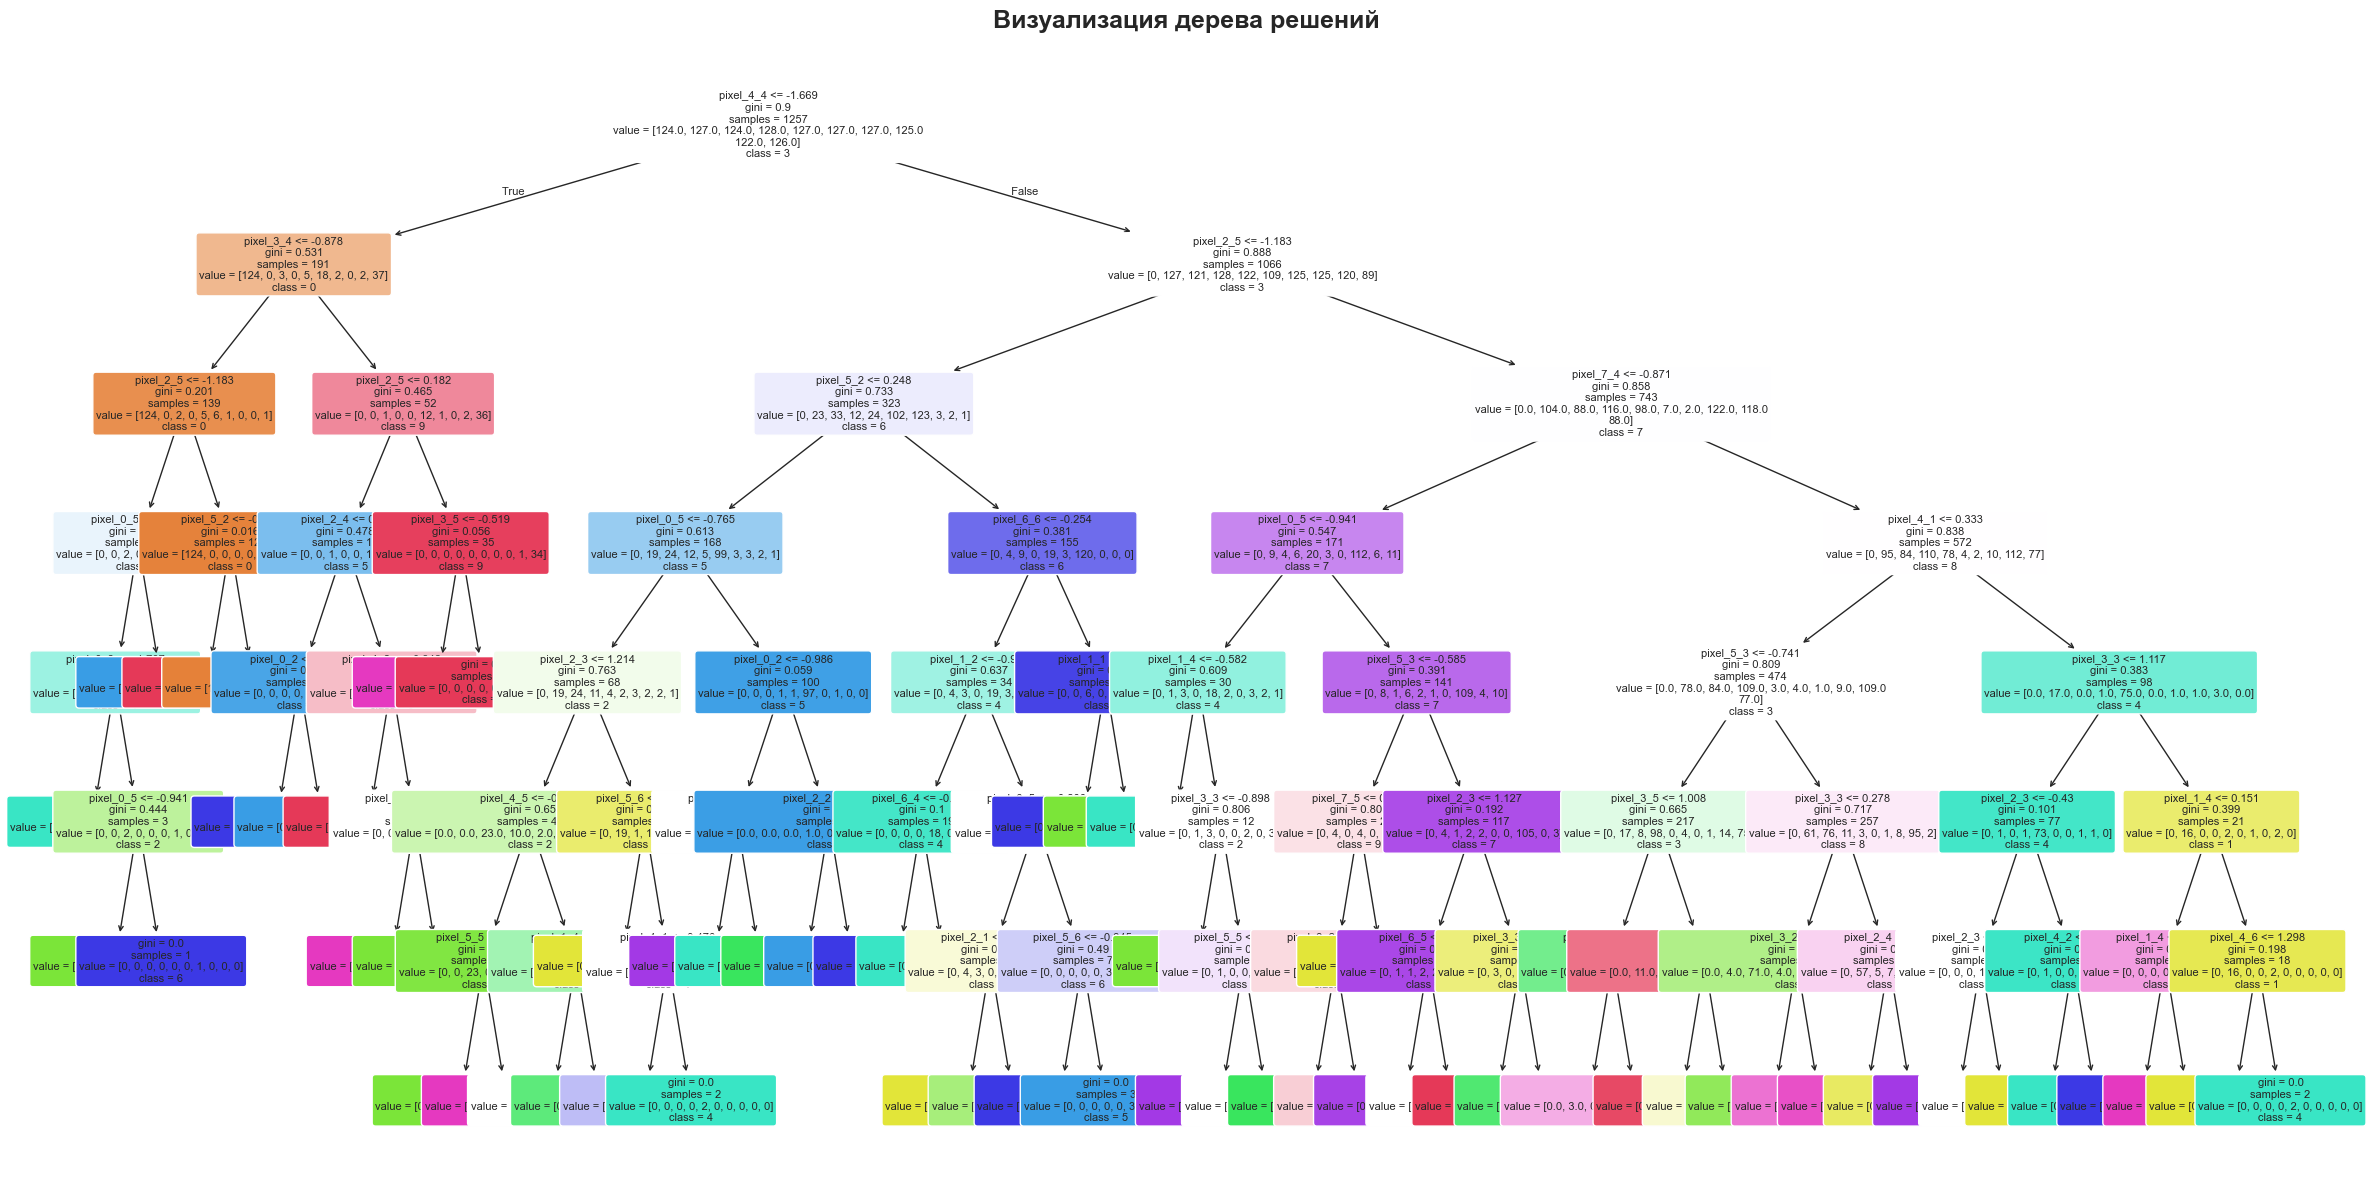

In [120]:
fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=digits.feature_names,
    class_names=[str(x) for x in digits.target_names],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Визуализация дерева решений', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()